In [422]:
import pandas as pd
import os
import xml.etree.ElementTree as ET

from ast import literal_eval

POLARITIES_MAPPING = {'positive': 'POSITIVE', 'neutral': 'NEUTRAL', 'negative': 'NEGATIVE'}

def readDataset(path):
    tree = ET.parse(path)
    root = tree.getroot()
    
    annotations = []
    sample_id = 0
    
    for doc in root.findall('.//sentence'):
        text = doc.find('.//text').text
        label_list = []
        label_list_phrases = []
    
        opinions = doc.findall('.//Opinion')
        if opinions:
            for op in doc.findall('.//Opinion'):
                # aspect = op.get('category').split('#')[0]
                aspect = op.get('category')
                # for key in ASPECTS_MAPPING.keys():
                #     aspect = aspect.replace(key, ASPECTS_MAPPING[key])
                polarity = op.get('polarity')
                for key in POLARITIES_MAPPING.keys():
                    polarity = polarity.replace(key, POLARITIES_MAPPING[key])

                phrase = op.get("target", "")
                phrase = phrase.replace('"', '')
                
                label_list.append((aspect.replace('#',' ').lower(), polarity.lower(), phrase))
            
        
            annotations.append([sample_id, text, label_list])
            sample_id += 1

    return annotations
    
def convert_to_list_of_tuples(data):
    try:
        parsed_data = literal_eval(data) if isinstance(data, str) else data
        
        if isinstance(parsed_data, list):
            return [literal_eval(item) if isinstance(item, str) else item for item in parsed_data]
        
        return parsed_data
    except (ValueError, SyntaxError):
        return None
        
def loadDataset(data_path):

    converters = {'labels': convert_to_list_of_tuples}
    
    df_train = pd.read_csv(os.path.join(data_path, 'train.tsv'), sep='\t', converters=converters).set_index('id')
    df_eval = pd.read_csv(os.path.join(data_path, 'test.tsv'), sep='\t', converters=converters).set_index('id')
        
    return df_train, df_eval

In [439]:
###
#   Transform original SemEval data to tsv-format
###

PATH = '../data/restaurant/'

def filterConflict(labels):
    return True in [pol == 'conflict' for asp, pol, phr in labels]
    
dataset_folders = [folder for folder in os.listdir(os.path.join(PATH)) if os.path.isdir(os.path.join(PATH, folder)) and folder != '.ipynb_checkpoints']
print(dataset_folders)
for folder in dataset_folders:
    try:
        annotations_train = readDataset(os.path.join(PATH, folder, 'train.xml'))
        annotations_test = readDataset(os.path.join(PATH, folder, 'test.xml'))
        
        columns = ['id', 'text', 'labels']
        
        train = pd.DataFrame(annotations_train, columns = columns)
        test = pd.DataFrame(annotations_test, columns = columns)
        
        train = train[~train['labels'].apply(filterConflict)]
        test = test[~test['labels'].apply(filterConflict)]
        
        train.to_csv(f'../data/restaurant/{folder}/train.tsv', encoding = 'utf-8', sep = '\t', index=False)
        test.to_csv(f'../data/restaurant/{folder}/test.tsv', encoding = 'utf-8', sep = '\t', index=False)
        train.to_json(f'../data/restaurant/{folder}/train.json', orient="records", lines=True)
        test.to_json(f'../data/restaurant/{folder}/test.json', orient="records", lines=True)
    except:
        print("No files found for lang: ", folder)

['nl', 'tr', 'ru', 'es', 'fr', 'cs', 'en', 'de']
No files found for lang:  de


In [420]:
###
#   Create custom GERestaurant dataset for annotation 
#   Select samples not yet annotated by Hellwig et al.
###

import pandas as pd
import ast
import re

def parse_gerest(file_path):
    """
    Parses a custom dataset formatted with '####' as a separator.

    Args:
        file_path (str): Path to the dataset file.

    Returns:
        pd.DataFrame: A DataFrame with two columns: 'Text' and 'Annotations'.
    """
    # Read the file into a DataFrame
    df = pd.read_csv(file_path, sep='####', header=None, names=['text', 'labels'], engine='python')
    
    # Convert the 'Annotations' column into a list of tuples
    def convert_annotations(annotations):
        try:
            return [tuple(item) for item in ast.literal_eval(annotations)]
        except (ValueError, SyntaxError):
            return None  # Handle malformed data gracefully

    # Apply the conversion function to the 'Annotations' column
    df['labels'] = df['labels'].apply(convert_annotations)
    
    return df

# Parsing original GERestaurant with 5 classes
def parse_annotations_gerestaurant(annotation_str):
    """Parses aspect annotations into a list of tuples from dataset without subaspects."""
    try:
        # Remove outer brackets and extract content inside parentheses
        annotation_str = annotation_str.strip("[]")  # Remove outer brackets
        matches = re.findall(r"\(([^)]+)\)", annotation_str)  # Extract tuples from parentheses
        
        # Parse each extracted match into a tuple
        parsed_annotations = []
        for match in matches:
            elements = [elem.strip().strip('"') for elem in match.split(",")]  # Split and clean elements
            if len(elements) == 3:  # Ensure only valid (ASPECT, POLARITY, PHRASE) tuples
                parsed_annotations.append(tuple(elements))
        
        return parsed_annotations
    except Exception as e:
        print(f"Parsing failed for without-subaspects annotations: {annotation_str} - Error: {e}")
        return []

split = 'train'
        
path_gerest = os.path.join(PATH, 'de', f'{split}.txt')
df_gerest = parse_gerest(path_gerest)

# Load the dataset without subaspects
path_gerestaurant = os.path.join(PATH, 'de', f'{split}_5sub.tsv')
df_gerestaurant = pd.read_csv(path_gerestaurant, sep='\t')

# Apply parsing function
df_gerestaurant['labels_phrases'] = df_gerestaurant['labels_phrases'].apply(parse_annotations_gerestaurant)
df_gerestaurant = df_gerestaurant[['text', 'labels_phrases']] 
df_gerestaurant.columns = ['text', 'labels']

df_overlap = pd.concat([df_gerest, df_gerestaurant]).drop_duplicates(subset='text', keep=False)

columns = ['labels_' + str(i) for i in range(df_overlap['labels'].apply(len).max())]
df_overlap[columns] = pd.DataFrame(df_overlap.labels.tolist(), index= df_overlap.index)

df_overlap = df_overlap.drop(['labels'], axis = 1)
df_overlap = df_overlap.fillna(value="")

df_text_only = df_overlap[['text']].copy()  # Keep only the text column
for col in columns:
    df_text_only[col] = ""  # Set all label columns to None
        
df_annotation = pd.concat([df_overlap, df_text_only], ignore_index=True).sort_values(by=['text', 'labels_0']).reset_index(drop=True)
df_annotation.to_csv(os.path.join(PATH, 'de', f'annotations_{split}.csv'), encoding = 'utf-8')

In [701]:
###
#  Merge annotations with original dataset
###

import numpy as np

aspect_dict = {
    'rg': 'restaurant general',
    'rm': 'restaurant miscellaneous',
    'rp': 'restaurant prices',
    'fq': 'food quality',
    'fs': 'food style_options',
    'fp': 'food prices',
    'dq': 'drinks quality',
    'ds': 'drinks style_options',
    'dp': 'drinks prices',
    'sg': 'service general',
    'ag': 'ambience general',
    'lg': 'location general'
}

def convertAnnotations(cell):
    try:
        return ast.literal_eval(cell)
    except:
        return cell
        
split = 'train'

path_annotations = os.path.join(PATH, 'de', f'annotations_{split}_finished.tsv')
df_annotations = pd.read_csv(path_annotations, sep = '\t', index_col = 0, encoding = 'utf_8', quoting =3)

label_cols = df_annotations.columns[1:]
for col in label_cols:
    df_annotations[col] = df_annotations[col].apply(convertAnnotations)

path_gerest = os.path.join(PATH, 'de', f'{split}.txt')
df_gerest = parse_gerest(path_gerest)

rows_cleaned = []

# Iterate over pairs of rows (original + annotation)
for i in range(0, len(df_annotations), 2):
    if i + 1 >= len(df_annotations):  # Ensure we don't go out of bounds
        break

    row_orig = df_annotations.iloc[i].copy()
    row_new = df_annotations.iloc[i + 1]

    annotated_cols = [col for col in df_annotations.columns[1:] if pd.notna(row_new[col])]

    for col in annotated_cols:
        if pd.notna(row_orig[col]):  # Ensure the original cell contains valid data
            aspect = aspect_dict.get(row_new[col], row_new[col])  # Map aspect, fallback to original if missing
            row_orig[col] = (aspect, row_orig[col][1], row_orig[col][2])

    rows_cleaned.append(row_orig)
    
def condenseLabels(row):
    labels = []
    for col in label_cols:
        if row[col] is not np.nan:
            
            labels.append((row[col][0], row[col][1].lower(), row[col][2]))
    return labels
    
# Convert back to DataFrame
df_annotations_cleaned = pd.DataFrame(rows_cleaned)
df_annotations_cleaned['labels'] = df_annotations_cleaned.apply(condenseLabels, axis = 1)
df_annotations_cleaned.drop(inplace=True, columns = label_cols)

def reorderLabels(labels):
    labels_new = []
    for lab in labels:
        labels_new.append([lab[1], lab[2] ,lab[0]])
    return labels_new

df_gerest['labels'] = df_gerest['labels'].apply(reorderLabels)

df_combined = pd.concat([df_annotations_cleaned, df_gerest]).reset_index()
df_combined.drop(inplace=True, columns = ['index'])
df_combined.index.name = 'id'
df_combined.reset_index().to_json(os.path.join(PATH, 'de', f'{split}.json'), orient="records", lines=True)

In [742]:
###
#   Calculate ratios of balanced datasets
###

import pandas as pd
import os
import xml.etree.ElementTree as ET
import re
import ast
import csv

from io import StringIO
from ast import literal_eval
from collections import Counter

PATH = '../data/restaurant/'

dataset_folders = [folder for folder in os.listdir(os.path.join(PATH)) if os.path.isdir(os.path.join(PATH, folder)) and folder != '.ipynb_checkpoints']

dfs = {}
counters_asp = {}
counters_asp_pol = {}
counters_pol = {}

for folder in dataset_folders:        
    if folder != 'tr':
        df_train = pd.read_json(os.path.join(PATH, folder, 'test.json'), orient="records", lines=True).set_index('id')
        asp = [aspect for labels in df_train['labels'] for aspect, polarity, phrase in labels]
        asp_pol = [f'{aspect}#{polarity}' for labels in df_train['labels'] for aspect, polarity, phrase in labels]
        pol = [f'{polarity}' for labels in df_train['labels'] for aspect, polarity, phrase in labels]
        counters_asp[folder] = Counter(asp)
        counters_asp_pol[folder] = Counter(asp_pol)
        counters_pol[folder] = Counter(pol)
        dfs[folder] = df_train

###
#   Aspects
###

all_counts_asp = {}

for lang, counter in counters_asp.items():
    for attribute, value in counter.items():
        if attribute not in all_counts_asp:
            all_counts_asp[attribute] = []
        all_counts_asp[attribute].append(value)

lowest_values_asp = {}

for attribute, values in all_counts_asp.items():
    unique_values = sorted(set(values))
    lowest_values_asp[attribute] = unique_values[0] if unique_values[0] >= 10 else 10

###
#   Aspects + Polarities
###

all_counts_asp_pol = {}

for lang, counter in counters_asp_pol.items():
    for attribute, value in counter.items():
        if attribute not in all_counts_asp_pol:
            all_counts_asp_pol[attribute] = []
        all_counts_asp_pol[attribute].append(value)

lowest_values_asp_pol = {}

for attribute, values in all_counts_asp_pol.items():
    unique_values = sorted(set(values))
    lowest_values_asp_pol[attribute] = unique_values[0] if unique_values[0] >= 10 else 10

all_counts_pol = {}

for lang, counter in counters_pol.items():
    for attribute, value in counter.items():
        if attribute not in all_counts_pol:
            all_counts_pol[attribute] = []
        all_counts_pol[attribute].append(value)

lowest_values_pol = {}

for attribute, values in all_counts_pol.items():
    unique_values = sorted(set(values))
    lowest_values_pol[attribute] = unique_values[0] if unique_values[0] >= 10 else 10

In [743]:
###
#   Create new datasets based on balanced ratios
###

def filterAspPol(labels, asp_pol):
    return asp_pol in [f'{asp}#{pol}' for asp, pol, phr in labels]

def filterAsp(labels, asp):
    return asp in [asp for asp, pol, phr in labels]

balanced_langs = {}
balanced_counters_asp = {}
balanced_counters_asp_pol = {}
balanced_counters_pol = {}

for lang, df in dfs.items():
    balanced_langs[lang] = df.copy()[0:0]
    balanced_counters_asp[lang] = {}
    balanced_counters_asp_pol[lang] = {}
    balanced_counters_pol[lang] = {}

sorted_lowest_asp = sorted(lowest_values_asp.items(), key=lambda x: x[1], reverse = True)
sorted_lowest_asp_pol = sorted(lowest_values_asp_pol.items(), key=lambda x: x[1], reverse = True)
sorted_lowest_pol = sorted(lowest_values_pol.items(), key=lambda x: x[1], reverse = True)

for asp_pol, count in sorted_lowest_asp_pol:
    for lang, df in dfs.items():
        
        df_subset = df[df['labels'].apply(lambda x: filterAspPol(x, asp_pol))]
        df_already_in = df_subset.index.isin(balanced_langs[lang][balanced_langs[lang]['labels'].apply(lambda x: filterAspPol(x, asp_pol))].index)
        df_subset = df_subset[~df_already_in]
        if len(df_subset) >= (count-sum(df_already_in) if count-sum(df_already_in) >0 else 0):
            df_sample = df_subset.sample(n=(count-sum(df_already_in) if count-sum(df_already_in) >0 else 0), random_state=20)
        else:
            df_sample = df_subset
        balanced_langs[lang] = pd.concat([balanced_langs[lang], df_sample])
        balanced_counters_asp[lang][asp_pol.split('#')[0]] = len([asp for labels in balanced_langs[lang]['labels'] for asp, pol, phr in labels if asp == asp_pol.split('#')[0]])
        balanced_counters_asp_pol[lang][asp_pol] = len([f'{asp}#{pol}' for labels in balanced_langs[lang]['labels'] for asp, pol, phr in labels if f'{asp}#{pol}' == asp_pol])
        balanced_counters_pol[lang][asp_pol.split('#')[1]] = len([pol for labels in balanced_langs[lang]['labels'] for asp, pol, phr in labels if pol == asp_pol.split('#')[1]])
        # for asp_p in ['positive', 'neutral', 'negative']:
        #     balanced_counters_pol[lang][asp_p] = len([pol for labels in balanced_langs[lang]['labels'] for asp, pol, phr in labels if pol == asp_p])

In [744]:
for lang, df in dfs.items():
    print(lang, len(df))
    print(lang, len(df.drop_duplicates(subset=['text'])))

nl 450
nl 448
ru 902
ru 900
es 677
es 666
fr 583
fr 583
cs 757
cs 755
en 587
en 586
de 919
de 916


In [745]:
for lang, count in balanced_counters_pol.items():
    print(lang)
    print(count)

nl
{'positive': 347, 'negative': 190, 'neutral': 33}
ru
{'positive': 476, 'negative': 205, 'neutral': 61}
es
{'positive': 455, 'negative': 206, 'neutral': 44}
fr
{'positive': 394, 'negative': 252, 'neutral': 67}
cs
{'positive': 535, 'negative': 277, 'neutral': 103}
en
{'positive': 450, 'negative': 185, 'neutral': 43}
de
{'positive': 412, 'negative': 220, 'neutral': 46}


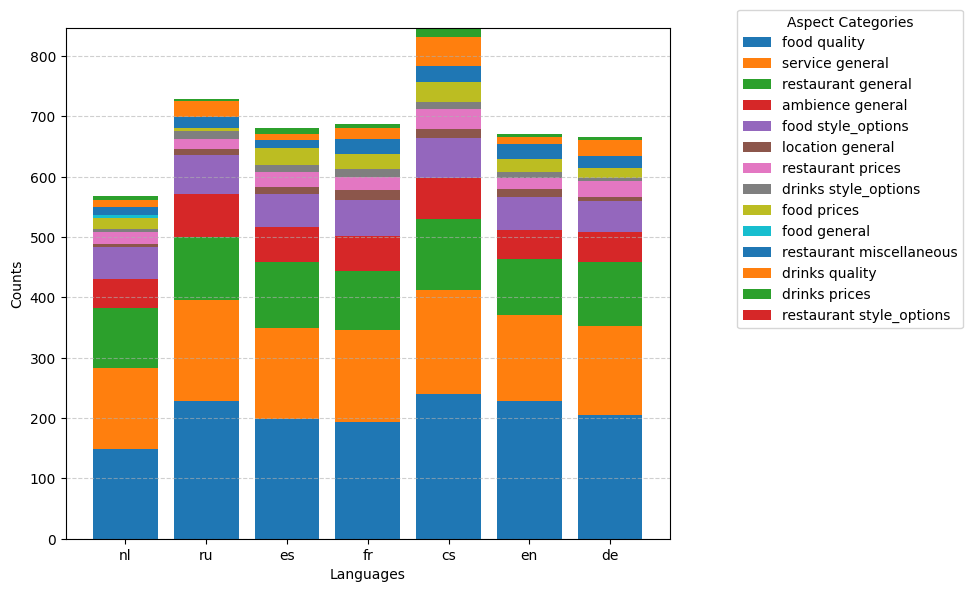

In [746]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Extrahiere die Sprachen und Kategorien
languages = list(balanced_counters_asp.keys())  # Sprachkürzel als X-Achse
categories = list(next(iter(balanced_counters_asp.values())).keys())  # Kategorien (Keys der Counter)

# Erstelle die Datenmatrix (Counts für jede Sprache und Kategorie)
values = np.array([[counter[cat] for cat in categories] for counter in balanced_counters_asp.values()])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Stapel-Balken zeichnen
bottoms = np.zeros(len(languages))  # Anfangshöhe der gestapelten Balken (initial 0)
for i, category in enumerate(categories):
    ax.bar(languages, values[:, i], label=category, bottom=bottoms)
    bottoms += values[:, i]  # Aktualisiere die Höhe für den nächsten Stapel

# Achsen und Titel
ax.set_xlabel("Languages")
ax.set_ylabel("Counts")
ax.legend(title="Aspect Categories", bbox_to_anchor=(1.1, 1.05))
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Layout
plt.tight_layout()
plt.show()


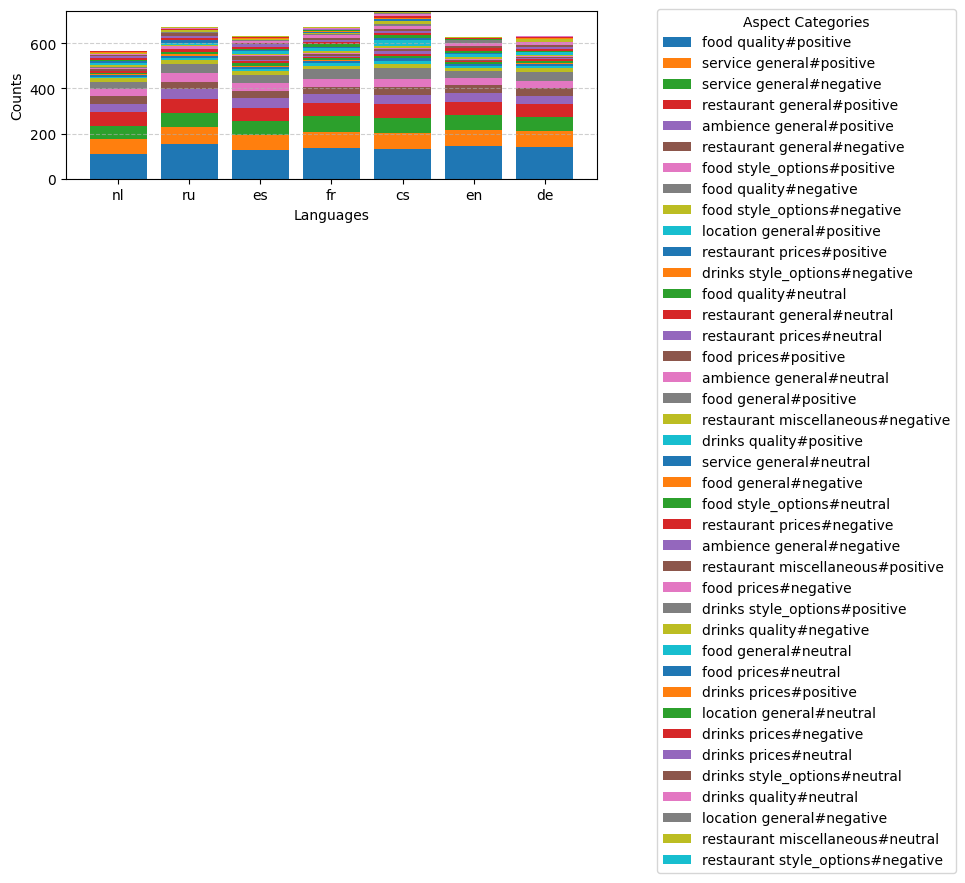

In [747]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Extrahiere die Sprachen und Kategorien
languages = list(balanced_counters_asp_pol.keys())  # Sprachkürzel als X-Achse
categories = list(next(iter(balanced_counters_asp_pol.values())).keys())  # Kategorien (Keys der Counter)

# Erstelle die Datenmatrix (Counts für jede Sprache und Kategorie)
values = np.array([[counter[cat] for cat in categories] for counter in balanced_counters_asp_pol.values()])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Stapel-Balken zeichnen
bottoms = np.zeros(len(languages))  # Anfangshöhe der gestapelten Balken (initial 0)
for i, category in enumerate(categories):
    ax.bar(languages, values[:, i], label=category, bottom=bottoms)
    bottoms += values[:, i]  # Aktualisiere die Höhe für den nächsten Stapel

# Achsen und Titel
ax.set_xlabel("Languages")
ax.set_ylabel("Counts")
ax.legend(title="Aspect Categories", bbox_to_anchor=(1.1, 1.05))
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Layout
plt.tight_layout()
plt.show()


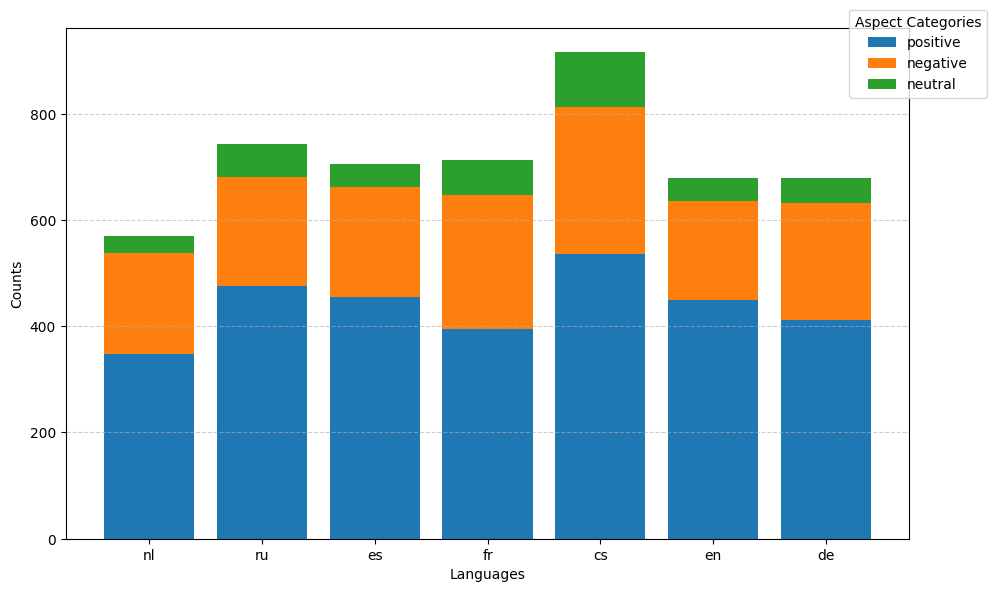

In [748]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Extrahiere die Sprachen und Kategorien
languages = list(balanced_counters_pol.keys())  # Sprachkürzel als X-Achse
categories = list(next(iter(balanced_counters_pol.values())).keys())  # Kategorien (Keys der Counter)

# Erstelle die Datenmatrix (Counts für jede Sprache und Kategorie)
values = np.array([[counter[cat] for cat in categories] for counter in balanced_counters_pol.values()])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Stapel-Balken zeichnen
bottoms = np.zeros(len(languages))  # Anfangshöhe der gestapelten Balken (initial 0)
for i, category in enumerate(categories):
    ax.bar(languages, values[:, i], label=category, bottom=bottoms)
    bottoms += values[:, i]  # Aktualisiere die Höhe für den nächsten Stapel

# Achsen und Titel
ax.set_xlabel("Languages")
ax.set_ylabel("Counts")
ax.legend(title="Aspect Categories", bbox_to_anchor=(1.1, 1.05))
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Layout
plt.tight_layout()
plt.show()
